# Modelo de crecimiento tumoral contra respuesta inmune

Sistema de 2 ecuaciones diferenciales ordinadas no lineales que describe el comportamiento de las células efectoras E (respuesta inmune) y células tumorales (T)

**Variables:**
- E = Células efectoras
- T = Células tumorales

**Ecuaciones:**
$$\frac{dE}{dt} = s + \frac{pET}{g+T} - mET - dE$$

$$\frac{dT}{dt} = aT(1 - bT) - nET$$

## Parámetros del modelo

Valores estimados por Kuznetsov(1992) para el linfoma BCL1 en ratones quiméricos

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
# Tasa max de crecimiento tumoral (dia-1)
a = 0.18
# Inverso capacidad de carga del tejido (celulas-1)
b = 2e-9
# Influx basal de efectoras al sitio tumoral (celulas/dia)
s = 1.3e4
# Tasa de acumulacion estimulada de efectoras (día-1)       
p = 0.1245
# Semisaturacion de la respuesta inmune (celulas)       
g = 2.019e7
# Tasa de inactivacion de efectoras por tumor (dia-1*celulas-1)       
m = 3.422e-10
# Tasa de lisis tumoral por efectoras (dia-1*celulas-1)     
n = 1.101e-7
# Muerte natural - migracion de efectoras (dia-1)      
d = 0.0412

## Sistema de ecuaciones

La función `sistema` recibe el tiempo `t` y el estado actual `y = [E, T]` 
y devuelve las derivadas `[dE/dt, dT/dt]`

In [21]:
def sistema(t, y):
    E, T = y
    dEdt = s + (p*E*T)/(g+T) - m*E*T - d*E
    dTdt = a*T*(1-b*T) - n*E*T
    return np.array([dEdt, dTdt])

## Condiciones iniciales

- `E0 = 3.3*10^5`: el bazo de un ratón BALB/c tiene ~10⁸ esplenocitos, 
  el 0.3% son CTL reactivos al BCL1
- `T0 = 1*10^6`: dosis inicial de células tumorales inyectadas

In [22]:
# Condiciones iniciales
E0 = 3.3e5
T0 = 1e6
yi = [E0, T0]

# Parámetros de simulación
xi   = 0
xFin = 365
h    = 0.5

## Método de Euler

$$y_{n+1} = y_n + h \cdot f(x_n, y_n)$$

In [23]:
def euler(f, h, xi, yi, xFin):
    x = xi
    y = np.array(yi)
    xout = [x]
    yout = [y]
    while x < xFin:
        if x + h > xFin:
            h = xFin - x
        y = y + h * f(x, y)
        x = x + h
        xout.append(x)
        yout.append(y)
    return xout, yout

tiempoEuler, solucionEuler = euler(sistema,h,xi,yi,xFin)

print("E final Euler:", solucionEuler[-1][0])
print("T final Euler:", solucionEuler[-1][1])

E final Euler: 1595198.7800673454
T final Euler: 13289041.084343523


## Método de Euler Mejorado
$$y_{pred} = y_n + h \cdot f(x_n, y_n)$$
$$y_{n+1} = y_n + \frac{h}{2}(f(x_n, y_n) + f(x_n+h, y_{pred}))$$

In [24]:
def eulerMejorado(f, h, xi, yi, xFin):
    x = xi
    y = np.array(yi)
    xout = [x]
    yout = [y]
    while x < xFin:
        if x + h > xFin:
            h = xFin - x
        y_pred = y + h * f(x, y)
        y = y + (h/2) * (f(x, y) + f(x + h, y_pred))
        x = x + h
        xout.append(x)
        yout.append(y)
    return xout, yout

tiempoEulerMejorado, solucionEulerMejorado = eulerMejorado(sistema,h,xi,yi,xFin)

print("E final Euler Mejorado:", solucionEulerMejorado[-1][0])
print("T final Euler Mejorado:", solucionEulerMejorado[-1][1])

E final Euler Mejorado: 1646230.914755241
T final Euler Mejorado: 11814596.272649577


## Método de Runge-Kutta de orden 4 (RK4)
$$y_{n+1} = y_n + \frac{h}{6}(k_1 + 2k_2 + 2k_3 + k_4)$$

In [25]:
def rk4(f, h, xi, yi, xFin):
    x = xi
    y = np.array(yi)
    xout = [x]
    yout = [y]
    while x < xFin:
        if x + h > xFin:
            h = xFin - x
        k1 = f(x,y)
        k2 = f(x + h/2, y + h/2 * k1)
        k3 = f(x + h/2, y + h/2 * k2)
        k4 = f(x + h, y + h * k3)
        y = y + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
        x = x + h
        xout.append(x)
        yout.append(y)
    return xout, yout

tiempoRK4, solucionRK4 = rk4(sistema,h,xi,yi,xFin)

print("E final RK4:", solucionRK4[-1][0])
print("T final RK4:", solucionRK4[-1][1])

E final RK4: 1645971.1320434473
T final RK4: 11820818.982420688


## Análisis de error

Comparación de los tres metodos con diferentes tamaños de paso `h`
contra RK45 de scipy como referencia

In [26]:
referencia = solve_ivp(sistema, [xi, xFin], yi, method='RK45', max_step=0.01)
E_ref = referencia.y[0][-1]
T_ref = referencia.y[1][-1]
print("Referencia RK45 — E:", E_ref)
print("Referencia RK45 — T:", T_ref)

Referencia RK45 — E: 1645971.16501154
Referencia RK45 — T: 11820819.431714317


Para el análisis del error se crean estas tabla con ayuda de la IA copilot para que se vea estética y sea fácil de entender

In [27]:
# ─── Análisis de error ────────────────────────────────────────────────────────
pasos = [0.1, 0.5, 1, 2, 5]

print("=" * 95)
print(f"{'h':>6} │ {'Método':<18} │ {'E final':>15} │ {'T final':>15} │ {'Error E':>12} │ {'Error T':>12}")
print("─" * 95)

for paso in pasos:
    tiempoEuler,         solucionEuler         = euler(sistema, paso, xi, yi, xFin)
    tiempoEulerMejorado, solucionEulerMejorado = eulerMejorado(sistema, paso, xi, yi, xFin)
    tiempoRK4,           solucionRK4           = rk4(sistema, paso, xi, yi, xFin)
    ref_paso = solve_ivp(sistema, [xi, xFin], yi, method='RK45', max_step=paso)

    E_ref_paso = ref_paso.y[0][-1]
    T_ref_paso = ref_paso.y[1][-1]

    metodos = [
        ("RK45 (referencia)", [E_ref_paso, T_ref_paso]),
        ("Euler",              solucionEuler[-1]),
        ("Euler Mejorado",     solucionEulerMejorado[-1]),
        ("RK4",                solucionRK4[-1]),
    ]

    for i, (nombre, sol) in enumerate(metodos):
        E_fin  = sol[0]
        T_fin  = sol[1]
        errorE = abs(E_fin - E_ref_paso)
        errorT = abs(T_fin - T_ref_paso)
        h_col  = f"{paso}" if i == 0 else ""
        ref_marker = "─" if i == 0 else ""
        print(f"{h_col:>6} │ {nombre:<18} │ {E_fin:>15.2f} │ {T_fin:>15.2f} │ {errorE:>12.2f} │ {errorT:>12.2f}")

    print("─" * 95)

print("=" * 95)

     h │ Método             │         E final │         T final │      Error E │      Error T
───────────────────────────────────────────────────────────────────────────────────────────────
   0.1 │ RK45 (referencia)  │      1645971.17 │     11820819.43 │         0.00 │         0.00
       │ Euler              │      1639151.49 │     12090280.05 │      6819.67 │    269460.62
       │ Euler Mejorado     │      1645980.55 │     11820576.96 │         9.39 │       242.47
       │ RK4                │      1645971.16 │     11820819.43 │         0.00 │         0.00
───────────────────────────────────────────────────────────────────────────────────────────────
   0.5 │ RK45 (referencia)  │      1645971.17 │     11820819.43 │         0.00 │         0.00
       │ Euler              │      1595198.78 │     13289041.08 │     50772.39 │   1468221.65
       │ Euler Mejorado     │      1646230.91 │     11814596.27 │       259.75 │      6223.16
       │ RK4                │      1645971.13 │     1182

In [29]:
pasos = [0.1, 0.5, 1, 2, 5]
mostrar_tabla = False  # ← cambia a True si quieres ver la tabla completa

erroresE = {"Euler": [], "Euler Mejorado": [], "RK4": []}
erroresT = {"Euler": [], "Euler Mejorado": [], "RK4": []}

for paso in pasos:
    tiempoEuler,         solucionEuler         = euler(sistema, paso, xi, yi, xFin)
    tiempoEulerMejorado, solucionEulerMejorado = eulerMejorado(sistema, paso, xi, yi, xFin)
    tiempoRK4,           solucionRK4           = rk4(sistema, paso, xi, yi, xFin)
    ref_paso = solve_ivp(sistema, [xi, xFin], yi, method='RK45', max_step=paso)

    E_ref_paso = ref_paso.y[0][-1]
    T_ref_paso = ref_paso.y[1][-1]

    metodos = [
        ("Euler",          solucionEuler[-1]),
        ("Euler Mejorado", solucionEulerMejorado[-1]),
        ("RK4",            solucionRK4[-1]),
    ]

    for nombre, sol in metodos:
        erroresE[nombre].append(abs(sol[0] - E_ref_paso))
        erroresT[nombre].append(abs(sol[1] - T_ref_paso))

# Métricas
print("=" * 75)
print(f"  Métricas de error global (sobre los 5 valores de h)")
print("=" * 75)
print(f"{'Método':<18} │ {'MAE E':>12} │ {'RMSE E':>12} │ {'MAE T':>12} │ {'RMSE T':>12}")
print("─" * 75)

for nombre in ["Euler", "Euler Mejorado", "RK4"]:
    eE = np.array(erroresE[nombre])
    eT = np.array(erroresT[nombre])
    print(f"{nombre:<18} │ {np.mean(eE):>12.2f} │ {np.sqrt(np.mean(eE**2)):>12.2f} │ {np.mean(eT):>12.2f} │ {np.sqrt(np.mean(eT**2)):>12.2f}")

print("=" * 75)

  Métricas de error global (sobre los 5 valores de h)
Método             │        MAE E │       RMSE E │        MAE T │       RMSE T
───────────────────────────────────────────────────────────────────────────
Euler              │    383661.61 │    587452.06 │   3356226.70 │   5113419.89
Euler Mejorado     │     10576.60 │     20685.00 │    207165.20 │    402668.28
RK4                │        92.40 │       205.07 │      3251.34 │      7183.27


Podemos ver con los resultados y la smetricas obtenidas que el RK4 es el método que mejor resultaqdos nos dió, teniendo peor valores en las celulas tumorales aunque manteniendose estable en comparación con los otros métodos, siendo el euler el de peor resultados acumulando errores catastroficos en las celulas calculadas.

## Simulaciones de casos interesantes

Se analizan tres comportamientos cualitativamente distintos del sistema
variando las condiciones iniciales y parámetros.

### Caso 1: Dormancia tumoral

Tumor pequeño/mediano — sistema inmune lo reconoce y controla, el cuerpo es capaz de reconocer el tumor y lanza una correcta respuesta inmune para combatirlo, logrando controlarlo y estabilizarlo

In [1]:
E0_c1 = 3.3e5
T0_c1 = 1e6
yi_c1  = [E0_c1, T0_c1]

xFin_largo = 1500

tiempoCaso1, solucionCaso1 = rk4(sistema, 0.5, xi, yi_c1, xFin_largo)

E_c1 = [sol[0] for sol in solucionCaso1]
T_c1 = [sol[1] for sol in solucionCaso1]

plt.figure(figsize=(10, 4))
plt.plot(tiempoCaso1, E_c1, label='Efectoras (E)', color='steelblue')
plt.plot(tiempoCaso1, T_c1, label='Tumorales (T)', color='tomato')
plt.xlabel('Tiempo (días)')
plt.ylabel('Células')
plt.title('Caso 1 — Dormancia tumoral')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

NameError: name 'rk4' is not defined

### Caso 2: Escape tumoral
Tumor grande — sistema inmune insuficiente para combatirlo, el tumor crece sin control y a pesar que el sistema inmune hace el mayor esfuerzo no es capaz de controlarlo

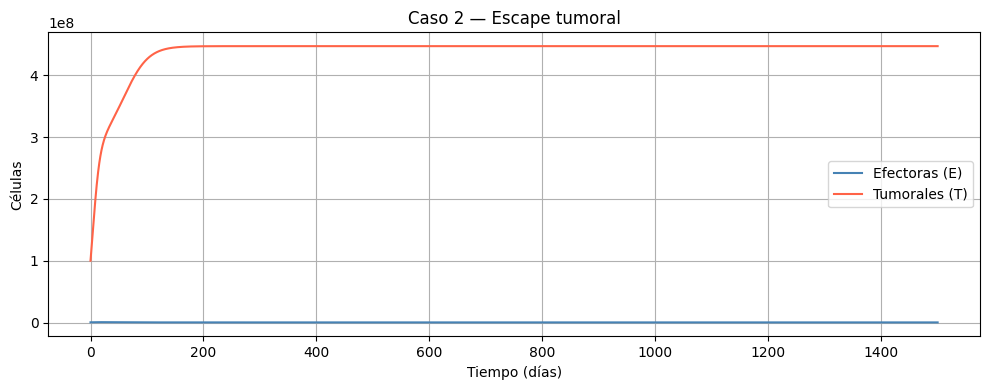

In [ ]:

E0_c2 = 3.3e5
T0_c2 = 1e8
yi_c2  = [E0_c2, T0_c2]

xFin_largo = 1500

tiempoCaso2, solucionCaso2 = rk4(sistema, 0.5, xi, yi_c2, xFin_largo)

E_c2 = [sol[0] for sol in solucionCaso2]
T_c2 = [sol[1] for sol in solucionCaso2]

plt.figure(figsize=(10, 4))
plt.plot(tiempoCaso2, E_c2, label='Efectoras (E)', color='steelblue')
plt.plot(tiempoCaso2, T_c2, label='Tumorales (T)', color='tomato')
plt.xlabel('Tiempo (días)')
plt.ylabel('Células')
plt.title('Caso 2 — Escape tumoral')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Caso 3: Sneaking through
La cantidad de celulas tumorales es tan baja que el sistema inmune manda una respuesta ineficaz, permitiendo el crecimiento del tumor y se salga de control

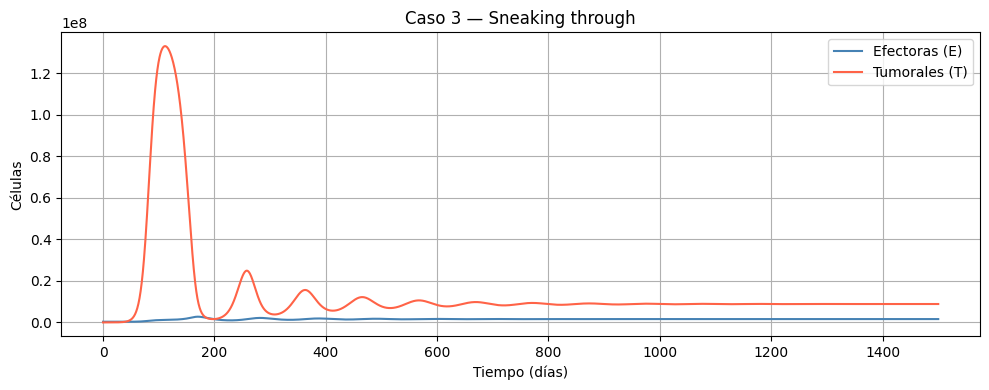

In [ ]:
m_original = m
m = m * 1.6

T0_d = 1e3
yi_d = [3.3e5, T0_d]
tiempoD, solucionD = rk4(sistema, 0.5, xi, yi_d, 1500)

E_d = [sol[0] for sol in solucionD]
T_d = [sol[1] for sol in solucionD]

plt.figure(figsize=(10, 4))
plt.plot(tiempoD, E_d, label='Efectoras (E)', color='steelblue')
plt.plot(tiempoD, T_d, label='Tumorales (T)', color='tomato')
plt.xlabel('Tiempo (días)')
plt.ylabel('Células')
plt.title('Caso 3 — Sneaking through')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

m = m_original

### Caso 4: Sensibilidad a condiciones iniciales — efecto separatriz
En este caso vemos como las condiciones iniciales de las celulas tumorales afectan el camino que toma este tumor, dandonos una contundente sensibilidad a los datos inciales

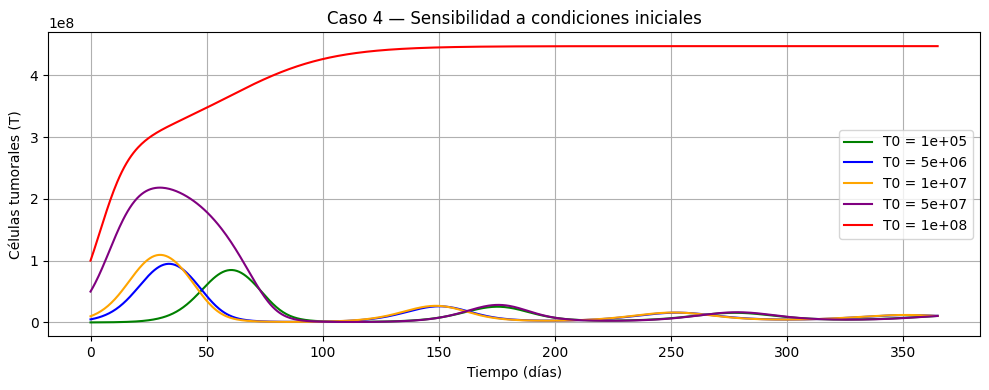

In [ ]:
m = m_original
dosis   = [1e5, 5e6, 1e7, 5e7, 1e8]
colores = ['green', 'blue', 'orange', 'purple', 'red']

plt.figure(figsize=(10, 4))
for T0_d, color in zip(dosis, colores):
    yi_d = [3.3e5, T0_d]
    tiempoD, solucionD = rk4(sistema, 0.5, xi, yi_d, 365)
    T_d = [sol[1] for sol in solucionD]
    plt.plot(tiempoD, T_d, label=f'T0 = {T0_d:.0e}', color=color)

plt.xlabel('Tiempo (días)')
plt.ylabel('Células tumorales (T)')
plt.title('Caso 4 — Sensibilidad a condiciones iniciales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()